In [1]:
import pandasql as ps
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df1 = pd.read_csv('mock_community_data.csv')
df2 = pd.read_csv('mock_hospital_data.csv')

In [3]:
df1.head()

,age,gender,location,health_issue,vaccination_status,symptoms,access_to_hospital,hospital_visits_last_year
0,34,F,Ibadan,Malaria,Yes,Fever;Chills,Yes,2
1,22,M,Lagos,Typhoid,No,Fever;Headache,No,0
2,45,F,Abuja,Cholera,Yes,Vomiting;Diarrhea,Yes,3
3,29,M,Kano,Malaria,No,Fever;Sweating,Yes,1
4,63,F,Enugu,NaN,Yes,NaN,Yes,0


In [4]:
df2.head()

,hospital_name,location,type,ownership,total_beds,icu_beds,ventilators,oxygen_supply,last_renovation_year,operational_status
0,PMC General Hospital - Aundh,Pune,General Hospital,Government,150,10,5,Yes,2018,Functional
1,PMC Maternity Home - Kothrud,Pune,Maternity Home,Government,40,2,1,Yes,2015,Functional
2,PMC Urban Health Center - Hadapsar,Pune,Health Center,Government,25,0,0,No,2010,Under Maintenance
3,PMC General Hospital - Yerwada,Pune,General Hospital,Private,120,8,4,Yes,2020,Functional
4,PMC Maternity Home - Shivajinagar,Pune,Maternity Home,Government,30,2,1,Yes,2016,Functional


In [25]:
Query = """
SELECT ownership ,SUM("total_beds") as Total_Beds 
FROM df2
GROUP BY ownership
"""

In [26]:
result = ps.sqldf(Query, locals())
result

,ownership,Total_Beds
0,Government,515
1,Private,200


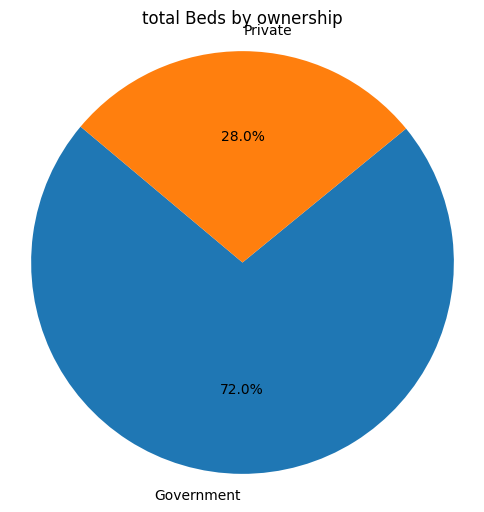

In [33]:
plt.figure(figsize=(6,6))
plt.pie(
    result['Total_Beds'],
    labels=result['ownership'],
    autopct='%1.1f%%',
    startangle=140
)
plt.title('total Beds by ownership')
plt.axis('equal')
plt.show()

In [60]:
Query2 = """
SELECT vaccination_status, gender , COUNT(*) as count
FROM df1
GROUP BY vaccination_status , gender
ORDER BY vaccination_status, gender
"""

In [61]:
result2 = ps.sqldf(Query2, locals())
result2

,vaccination_status,gender,count
0,No,M,6
1,Yes,F,6
2,Yes,M,1
3,yes,F,1


In [62]:
import seaborn as sns

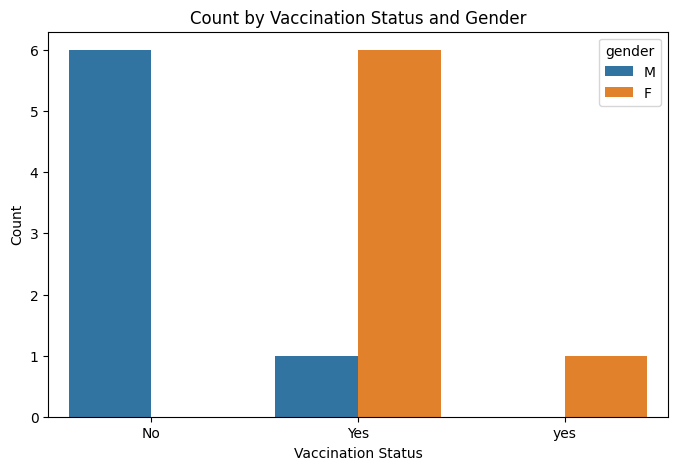

In [70]:
plt.figure(figsize=(8, 5))

sns.barplot(data=result2, x='vaccination_status', y='count', hue='gender')
plt.title('Count by Vaccination Status and Gender')
plt.ylabel('Count')
plt.xlabel('Vaccination Status')
plt.show()

In [71]:
Query3 = """
SELECT gender, access_to_hospital, COUNT(*) as count
FROM df1
GROUP BY gender, access_to_hospital
ORDER BY gender, access_to_hospital
"""

In [72]:
result3 = ps.sqldf(Query3, locals())
result3

,gender,access_to_hospital,count
0,F,Yes,7
1,M,No,5
2,M,Yes,2


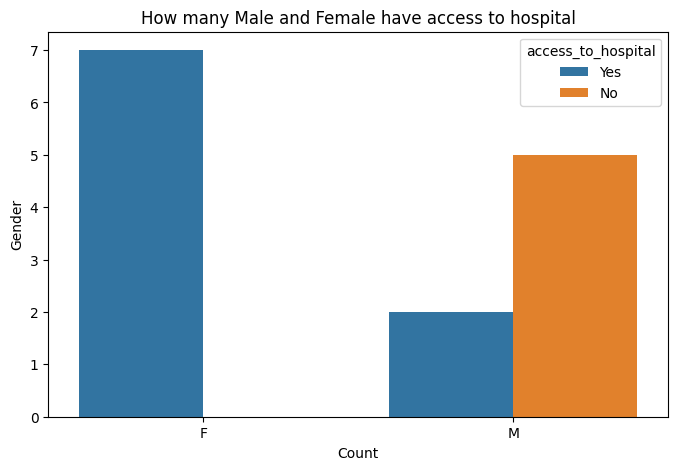

In [73]:
plt.figure(figsize=(8, 5))

sns.barplot(data=result3, x='gender', y='count', hue='access_to_hospital')
plt.title('How many Male and Female have access to hospital')
plt.ylabel('Gender')
plt.xlabel('Count')
plt.show()

In [74]:
Query4 = """
SELECT ownership, COUNT(*) as hospital_count
FROM df2
GROUP BY ownership
"""

In [75]:
result4 = ps.sqldf(Query4, locals())
result4

,ownership,hospital_count
0,Government,9
1,Private,3


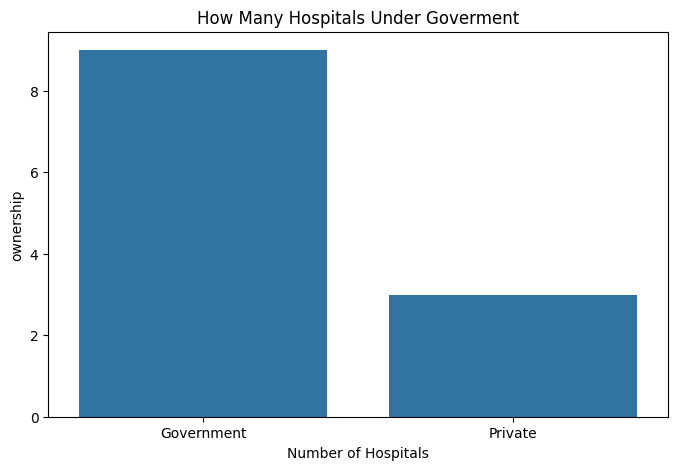

In [81]:
plt.figure(figsize=(8, 5))

sns.barplot(data=result4, x='ownership', y='hospital_count')
plt.title('How Many Hospitals Under Goverment')
plt.ylabel('ownership')
plt.xlabel('Number of Hospitals')
plt.show()